# 10 Minutes to pandas

Dieses Notebook ist eine kompakte, projektlokale Variante der bekannten `10 Minutes to pandas`-Einfuhrung. Es nutzt den Kernel aus der `.venv` dieses Projekts.

Die Erklarungen sind bewusst etwas ausfuhrlicher gehalten, damit du beim Ausfuhren direkt siehst, was in jeder Zelle gerade passiert.

## Setup

Falls dein Editor den Kernel nicht automatisch setzt, wahle `Python (.venv) - 260324-lv3` aus.

In [8]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

print("Bibliotheken geladen: numpy, pandas, matplotlib")
print("Die Anzeigeoptionen wurden etwas kompakter fur Notebook-Ausgaben gesetzt.")

Bibliotheken geladen: numpy, pandas, matplotlib
Die Anzeigeoptionen wurden etwas kompakter fur Notebook-Ausgaben gesetzt.


## 1. Objekte erzeugen

Wir starten mit den beiden wichtigsten pandas-Strukturen:

- `Series`: eine einzelne beschriftete Spalte
- `DataFrame`: eine tabellarische Struktur mit Zeilen und Spalten

In [9]:
print("Wir erzeugen zuerst eine Series. pandas vergibt automatisch einen Integer-Index.")
s = pd.Series([1, 3, 5, np.nan, 6, 8])
display(s)

print("Das NaN steht fur einen fehlenden Wert.")

Wir erzeugen zuerst eine Series. pandas vergibt automatisch einen Integer-Index.


0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

Das NaN steht fur einen fehlenden Wert.


In [10]:
print("Jetzt bauen wir ein DataFrame mit Datumsindex und vier numerischen Spalten.")
dates = pd.date_range("2026-01-01", periods=7)
df = pd.DataFrame(np.random.randn(7, 4), index=dates, columns=["Alpha", "Beta", "Gamma", "Delta"])
display(df)

print("Jede Zeile ist hier uber ein Datum identifizierbar.")

Jetzt bauen wir ein DataFrame mit Datumsindex und vier numerischen Spalten.


,Alpha,Beta,Gamma,Delta
2026-01-01,-0.294233,0.851422,-0.202499,0.181793
2026-01-02,0.608426,1.039834,0.584017,1.442145
2026-01-03,-0.180393,0.209096,-0.312775,1.064492
2026-01-04,0.286611,-1.257879,0.651775,0.699787
2026-01-05,-0.468585,1.956114,-1.657368,0.188396
2026-01-06,1.514950,0.080277,-0.334969,2.748226
2026-01-07,-0.867378,-0.525383,-0.440810,-0.299293


Jede Zeile ist hier uber ein Datum identifizierbar.


           A         B
0  -1.253216 -0.090900
1  -2.218746 -1.619165
2  -1.350555  0.144696
3   0.340048  0.489815
4   0.657030  0.735550
..       ...       ...
95 -1.002273 -1.420847
96  0.908272  0.355939
97  1.121149  0.984746
98  0.731506  0.715752
99  0.715188 -0.723524

[100 rows x 2 columns]
Eintrag:{testtable.iloc[3, 1]:.2f}


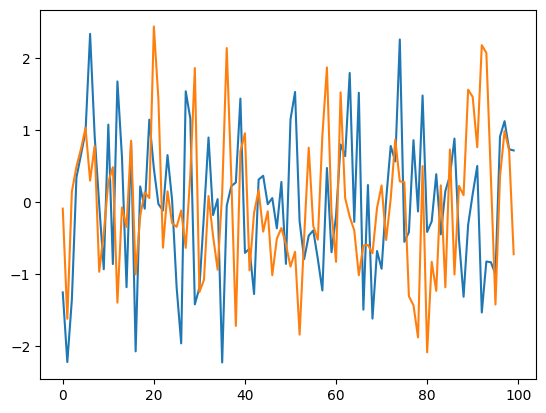

In [11]:
testtable = pd.DataFrame(np.random.randn(100, 2), columns=["A", "B"])
print(testtable)
print(f"Eintrag:" "{testtable.iloc[3, 1]:.2f}")

plt.plot(testtable[:][:])





In [12]:
display(df.head(3))
print("Mit head() sehen wir die ersten Zeilen eines DataFrames.")

,Alpha,Beta,Gamma,Delta
2026-01-01,-0.294233,0.851422,-0.202499,0.181793
2026-01-02,0.608426,1.039834,0.584017,1.442145
2026-01-03,-0.180393,0.209096,-0.312775,1.064492


Mit head() sehen wir die ersten Zeilen eines DataFrames.


In [13]:
print("pandas kann in einem DataFrame auch gemischte Datentypen verwalten.")
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("2026-01-01"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "hello",
    }
)
display(df2)
print("Hier sieht man Zahlen, Datum, Kategorie und Text in einer Tabelle.")

pandas kann in einem DataFrame auch gemischte Datentypen verwalten.


,A,B,C,D,E,F
0,1.0,2026-01-01,1.0,3,test,hello
1,1.0,2026-01-01,1.0,3,train,hello
2,1.0,2026-01-01,1.0,3,test,hello
3,1.0,2026-01-01,1.0,3,train,hello


Hier sieht man Zahlen, Datum, Kategorie und Text in einer Tabelle.


## 2. Daten ansehen

Bevor man mit Daten arbeitet, schaut man sich typischerweise Struktur, Kopfzeilen, Kennzahlen und Sortierung an.

In [14]:
print("head(): zeigt die ersten Zeilen fur einen schnellen Uberblick")
display(df.head())

print("tail(3): zeigt die letzten drei Zeilen")
display(df.tail(3))

print("index: der Zeilenindex des DataFrames")
display(df.index)

print("columns: die Spaltennamen")
display(df.columns)

print("to_numpy(): reine NumPy-Darstellung ohne Index und Spaltenbeschriftung")
display(df.to_numpy())

print("describe(): statistische Grundzusammenfassung fur numerische Spalten")
display(df.describe())

print("T: transponiert das DataFrame, also Zeilen und Spalten werden getauscht")
display(df.T)

print("sort_index(...): sortiert nach Spaltennamen statt nach Werten")
display(df.sort_index(axis=1, ascending=False))

print("sort_values(by='B'): sortiert die Zeilen nach den Werten in Spalte B")
display(df.sort_values(by="B"))

head(): zeigt die ersten Zeilen fur einen schnellen Uberblick


,Alpha,Beta,Gamma,Delta
2026-01-01,-0.294233,0.851422,-0.202499,0.181793
2026-01-02,0.608426,1.039834,0.584017,1.442145
2026-01-03,-0.180393,0.209096,-0.312775,1.064492
2026-01-04,0.286611,-1.257879,0.651775,0.699787
2026-01-05,-0.468585,1.956114,-1.657368,0.188396


tail(3): zeigt die letzten drei Zeilen


,Alpha,Beta,Gamma,Delta
2026-01-05,-0.468585,1.956114,-1.657368,0.188396
2026-01-06,1.514950,0.080277,-0.334969,2.748226
2026-01-07,-0.867378,-0.525383,-0.440810,-0.299293


index: der Zeilenindex des DataFrames


...

,2026-01-01,2026-01-02,2026-01-03,2026-01-04,2026-01-05,2026-01-06,2026-01-07
Alpha,-0.294233,0.608426,-0.180393,0.286611,-0.468585,1.514950,-0.867378
Beta,0.851422,1.039834,0.209096,-1.257879,1.956114,0.080277,-0.525383
Gamma,-0.202499,0.584017,-0.312775,0.651775,-1.657368,-0.334969,-0.440810
Delta,0.181793,1.442145,1.064492,0.699787,0.188396,2.748226,-0.299293


sort_index(...): sortiert nach Spaltennamen statt nach Werten


,Gamma,Delta,Beta,Alpha
2026-01-01,-0.202499,0.181793,0.851422,-0.294233
2026-01-02,0.584017,1.442145,1.039834,0.608426
2026-01-03,-0.312775,1.064492,0.209096,-0.180393
2026-01-04,0.651775,0.699787,-1.257879,0.286611
2026-01-05,-1.657368,0.188396,1.956114,-0.468585
2026-01-06,-0.334969,2.748226,0.080277,1.514950
2026-01-07,-0.440810,-0.299293,-0.525383,-0.867378


sort_values(by='B'): sortiert die Zeilen nach den Werten in Spalte B


KeyError: 'B'

## 3. Auswahl und Zugriff

Jetzt greifen wir auf einzelne Spalten, Teilbereiche und bestimmte Positionen zu.

In [ ]:
print("df['A']: holt eine einzelne Spalte als Series")
display(df["A"])

print("df[0:3]: Zeilenschnitt uber Positionen")
display(df[0:3])

print("loc[...]: label-basierter Zugriff, hier eine Zeile uber ihr Datum")
display(df.loc[dates[0]])

print("loc[:, ['A', 'B']]: alle Zeilen, aber nur die Spalten A und B")
display(df.loc[:, ["A", "B"]])

print("iloc[3]: positionsbasierter Zugriff auf die vierte Zeile")
display(df.iloc[3])

print("iloc[3:5, 0:2]: Zeilen 4-5 und Spalten 1-2 nach Position")
display(df.iloc[3:5, 0:2])

print("Mehrfachauswahl mit iloc fur bestimmte Zeilen- und Spaltenpositionen")
display(df.iloc[[1, 2, 4], [0, 2]])

print("Boolean Filtering: nur Zeilen, in denen Spalte A grosser als 0 ist")
display(df[df["A"] > 0])

df['A']: holt eine einzelne Spalte als Series


2026-01-01    0.039906
2026-01-02    1.348398
2026-01-03   -0.664313
2026-01-04    0.184313
2026-01-05    0.470847
2026-01-06    1.027308
Freq: D, Name: A, dtype: float64

df[0:3]: Zeilenschnitt uber Positionen


,A,B,C,D
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493
2026-01-02,1.348398,-0.326223,1.510516,1.179984
2026-01-03,-0.664313,-1.407011,0.023909,0.358722


loc[...]: label-basierter Zugriff, hier eine Zeile uber ihr Datum


...

,A,B
2026-01-04,0.184313,1.282014
2026-01-05,0.470847,0.772625


Mehrfachauswahl mit iloc fur bestimmte Zeilen- und Spaltenpositionen


,A,C
2026-01-02,1.348398,1.510516
2026-01-03,-0.664313,0.023909
2026-01-05,0.470847,-0.343336


Boolean Filtering: nur Zeilen, in denen Spalte A grosser als 0 ist


,A,B,C,D
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493
2026-01-02,1.348398,-0.326223,1.510516,1.179984
2026-01-04,0.184313,1.282014,-1.179533,0.317348
2026-01-05,0.470847,0.772625,-0.343336,1.778699
2026-01-06,1.027308,-1.909175,0.307802,1.402182


## 4. Werte setzen

Wir arbeiten auf einer Kopie, damit das ursprungliche `df` unverandert bleibt.

In [ ]:
df_copy = df.copy()
print("loc setzt einen Wert uber Zeilenlabel und Spaltenname.")
df_copy.loc[dates[0], "A"] = 0

print("iloc setzt einen Wert uber numerische Position.")
df_copy.iloc[1, 1] = 0

print("Hier fugen wir eine neue Spalte E hinzu.")
df_copy["E"] = ["one", "one", "two", "three", "four", "three"]
display(df_copy)

print("Das Ergebnis ist ein geandertes DataFrame mit zusatzlicher Textspalte.")

loc setzt einen Wert uber Zeilenlabel und Spaltenname.
iloc setzt einen Wert uber numerische Position.
Hier fugen wir eine neue Spalte E hinzu.


,A,B,C,D,E
2026-01-01,0.000000,-1.418427,-1.858072,-0.410493,one
2026-01-02,1.348398,0.000000,1.510516,1.179984,one
2026-01-03,-0.664313,-1.407011,0.023909,0.358722,two
2026-01-04,0.184313,1.282014,-1.179533,0.317348,three
2026-01-05,0.470847,0.772625,-0.343336,1.778699,four
2026-01-06,1.027308,-1.909175,0.307802,1.402182,three


Das Ergebnis ist ein geandertes DataFrame mit zusatzlicher Textspalte.


## 5. Fehlende Daten

Fehlende Werte sind im Alltag sehr haufig. pandas bietet dafUr viele eingebaute Werkzeuge.

In [ ]:
df_missing = df.reindex(index=dates[:4], columns=list(df.columns) + ["E"])
df_missing.loc[dates[0] : dates[1], "E"] = 1

print("reindex() erzeugt hier bewusst fehlende Werte, weil neue Struktur angefordert wurde.")
display(df_missing)

print("dropna(how='any'): entfernt alle Zeilen, die mindestens einen fehlenden Wert haben.")
display(df_missing.dropna(how="any"))

print("fillna(value=5): ersetzt fehlende Werte durch einen festen Wert.")
display(df_missing.fillna(value=5))

print("isna(): zeigt fur jede Zelle, ob dort ein fehlender Wert liegt.")
display(pd.isna(df_missing))

reindex() erzeugt hier bewusst fehlende Werte, weil neue Struktur angefordert wurde.


,A,B,C,D,E
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493,1.0
2026-01-02,1.348398,-0.326223,1.510516,1.179984,1.0
2026-01-03,-0.664313,-1.407011,0.023909,0.358722,NaN
2026-01-04,0.184313,1.282014,-1.179533,0.317348,NaN


dropna(how='any'): entfernt alle Zeilen, die mindestens einen fehlenden Wert haben.


,A,B,C,D,E
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493,1.0
2026-01-02,1.348398,-0.326223,1.510516,1.179984,1.0


fillna(value=5): ersetzt fehlende Werte durch einen festen Wert.


,A,B,C,D,E
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493,1.0
2026-01-02,1.348398,-0.326223,1.510516,1.179984,1.0
2026-01-03,-0.664313,-1.407011,0.023909,0.358722,5.0
2026-01-04,0.184313,1.282014,-1.179533,0.317348,5.0


isna(): zeigt fur jede Zelle, ob dort ein fehlender Wert liegt.


,A,B,C,D,E
2026-01-01,False,False,False,False,False
2026-01-02,False,False,False,False,False
2026-01-03,False,False,False,False,True
2026-01-04,False,False,False,False,True


## 6. Operationen

Viele Standardoperationen arbeiten direkt spaltenweise oder zeilenweise.

In [ ]:
print("mean(): Mittelwert pro Spalte")
display(df.mean())

print("mean(axis=1): Mittelwert pro Zeile")
display(df.mean(axis=1))

print("shift(2): verschiebt eine Series um zwei Zeilen nach unten.")
s_shifted = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
display(s_shifted)

print("sub(..., axis='index'): subtrahiert entlang des gemeinsamen Index.")
display(df.sub(s_shifted, axis="index"))

print("apply(np.cumsum): kumulative Summe innerhalb jeder Spalte")
display(df.apply(np.cumsum))

print("apply(lambda ...): Spannweite pro Spalte, also max minus min")
display(df.apply(lambda x: x.max() - x.min()))

mean(): Mittelwert pro Spalte


A    0.401077
B   -0.501033
C   -0.256453
D    0.771074
dtype: float64

mean(axis=1): Mittelwert pro Zeile


2026-01-01   -0.911772
2026-01-02    0.928169
2026-01-03   -0.422173
2026-01-04    0.151035
2026-01-05    0.669709
2026-01-06    0.207029
Freq: D, dtype: float64

shift(2): verschiebt eine Series um zwei Zeilen nach unten.


...

,A,B,C,D
2026-01-01,NaN,NaN,NaN,NaN
2026-01-02,NaN,NaN,NaN,NaN
2026-01-03,-1.664313,-2.407011,-0.976091,-0.641278
2026-01-04,-2.815687,-1.717986,-4.179533,-2.682652
2026-01-05,-4.529153,-4.227375,-5.343336,-3.221301
2026-01-06,NaN,NaN,NaN,NaN


apply(np.cumsum): kumulative Summe innerhalb jeder Spalte


,A,B,C,D
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493
2026-01-02,1.388304,-1.744650,-0.347556,0.769491
2026-01-03,0.723992,-3.151661,-0.323647,1.128213
2026-01-04,0.908304,-1.869647,-1.503181,1.445561
2026-01-05,1.379152,-1.097022,-1.846517,3.224260
2026-01-06,2.406460,-3.006198,-1.538716,4.626442


apply(lambda ...): Spannweite pro Spalte, also max minus min


A    2.012711
B    3.191190
C    3.368587
D    2.189192
dtype: float64

## 7. Histogramm, Strings und Kategorien

pandas kann auch Haufikeiten zahlen, Text spaltenweise transformieren und Kategorien effizient speichern.

In [ ]:
print("value_counts(): zahlt, wie oft jeder Wert vorkommt")
display(pd.Series(np.random.randint(0, 7, size=10)).value_counts())

s_text = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
print("str.lower(): wendet eine String-Operation auf jedes Element an")
display(s_text.str.lower())

df_cat = df_copy.copy()
df_cat["E"] = df_cat["E"].astype("category")
print("astype('category'): spart oft Speicher und zeigt, dass Spalte E kategorial ist")
display(df_cat.dtypes)

value_counts(): zahlt, wie oft jeder Wert vorkommt


5    5
0    2
2    2
1    1
Name: count, dtype: int64

str.lower(): wendet eine String-Operation auf jedes Element an


0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: object

astype('category'): spart oft Speicher und zeigt, dass Spalte E kategorial ist


A     float64
B     float64
C     float64
D     float64
E    category
dtype: object

## 8. Merge, GroupBy und Reshape

Hier sieht man drei typische Datenaufbereitungsaufgaben:

- Tabellen zusammenfuhren
- nach Gruppen aggregieren
- Daten zwischen langer und breiter Form umformen

In [ ]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
print("merge(...): verbindet zwei Tabellen uber die gemeinsame Schlusselspalte 'key'")
display(pd.merge(left, right, on="key"))

df_group = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
print("groupby('A').sum(): aggregiert die Werte je Gruppe in Spalte A")
display(df_group.groupby("A")[["C", "D"]].sum())

print("groupby(['A', 'B']): gruppiert uber zwei Schlussel gleichzeitig")
display(df_group.groupby(["A", "B"])["D"].sum())

stacked = df2.stack(future_stack=True)
print("stack(): macht aus Spalten eine tiefere Index-Ebene, also eine langere Darstellung")
display(stacked)

print("unstack(): dreht diesen Schritt wieder zuruck")
display(stacked.unstack())

merge(...): verbindet zwei Tabellen uber die gemeinsame Schlusselspalte 'key'


,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


groupby('A').sum(): aggregiert die Werte je Gruppe in Spalte A


,C,D
A,,
bar,-1.175813,-0.171025
foo,-3.597573,-0.073487


groupby(['A', 'B']): gruppiert uber zwei Schlussel gleichzeitig


A    B    
bar  one     -1.526940
     three    1.083229
     two      0.272686
foo  one      1.873258
     three    0.676349
     two     -2.623094
Name: D, dtype: float64

stack(): macht aus Spalten eine tiefere Index-Ebene, also eine langere Darstellung


0  A                    1.0
   B    2026-01-01 00:00:00
   C                    1.0
   D                      3
   E                   test
               ...         
3  B    2026-01-01 00:00:00
   C                    1.0
   D                      3
   E                  train
   F                  hello
Length: 24, dtype: object

unstack(): dreht diesen Schritt wieder zuruck


,A,B,C,D,E,F
0,1.0,2026-01-01 00:00:00,1.0,3,test,hello
1,1.0,2026-01-01 00:00:00,1.0,3,train,hello
2,1.0,2026-01-01 00:00:00,1.0,3,test,hello
3,1.0,2026-01-01 00:00:00,1.0,3,train,hello


## 9. Zeitreihen

Zeitbezogene Daten gehoren zu den Starken von pandas: Resampling, Zeitzonen und Datumsindizes sind direkt eingebaut.

In [ ]:
rng = pd.date_range("2026-01-01", periods=100, freq="s")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts_resampled = ts.resample("5min").sum()

print("Die erste Ausgabe zeigt einzelne Sekundenwerte.")
display(ts.head())

print("resample('5min').sum(): fasst alle Sekundenwerte zu 5-Minuten-Buckets zusammen.")
display(ts_resampled)

rng_tz = pd.date_range("2026-03-24 09:00", periods=5, freq="h", tz="UTC")
print("Zuerst die Datumswerte in UTC:")
display(rng_tz)

print("tz_convert('Europe/Vienna'): dieselben Zeitpunkte in anderer Zeitzone")
display(rng_tz.tz_convert("Europe/Vienna"))

Die erste Ausgabe zeigt einzelne Sekundenwerte.


2026-01-01 00:00:00    182
2026-01-01 00:00:01     33
2026-01-01 00:00:02    190
2026-01-01 00:00:03    329
2026-01-01 00:00:04     42
Freq: s, dtype: int32

resample('5min').sum(): fasst alle Sekundenwerte zu 5-Minuten-Buckets zusammen.


2026-01-01    24347
Freq: 5min, dtype: int32

Zuerst die Datumswerte in UTC:


DatetimeIndex(['2026-03-24 09:00:00+00:00', '2026-03-24 10:00:00+00:00', '2026-03-24 11:00:00+00:00',
               '2026-03-24 12:00:00+00:00', '2026-03-24 13:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='h')

tz_convert('Europe/Vienna'): dieselben Zeitpunkte in anderer Zeitzone


DatetimeIndex(['2026-03-24 10:00:00+01:00', '2026-03-24 11:00:00+01:00', '2026-03-24 12:00:00+01:00',
               '2026-03-24 13:00:00+01:00', '2026-03-24 14:00:00+01:00'],
              dtype='datetime64[ns, Europe/Vienna]', freq='h')

## 10. Plotten

pandas bietet einfache Plotting-Helfer, die auf matplotlib aufbauen.

Wir erzeugen eine kumulative Zufallsreihe. Durch cumsum() entsteht eine gut sichtbare Entwicklung uber die Zeit.


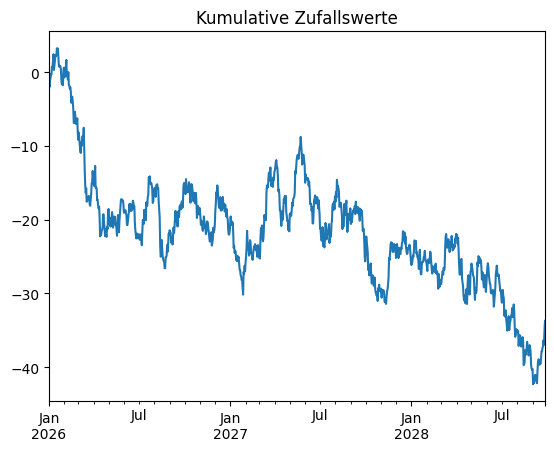

Nun ein DataFrame mit vier Spalten, ebenfalls kumuliert und gemeinsam geplottet.


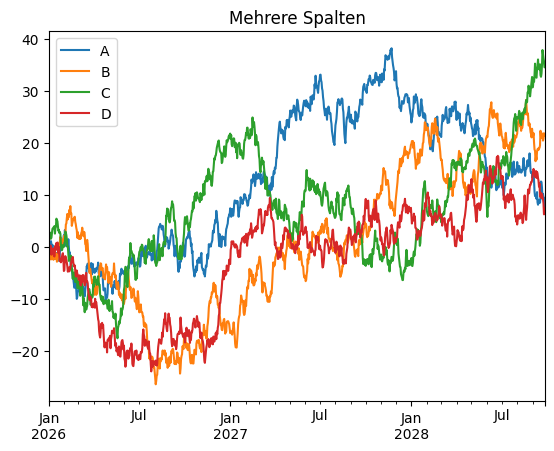

In [ ]:
print("Wir erzeugen eine kumulative Zufallsreihe. Durch cumsum() entsteht eine gut sichtbare Entwicklung uber die Zeit.")
ts_plot = pd.Series(np.random.randn(1000), index=pd.date_range("2026-01-01", periods=1000))
ts_plot = ts_plot.cumsum()
ts_plot.plot(title="Kumulative Zufallswerte")
plt.show()

print("Nun ein DataFrame mit vier Spalten, ebenfalls kumuliert und gemeinsam geplottet.")
df_plot = pd.DataFrame(np.random.randn(1000, 4), index=ts_plot.index, columns=list("ABCD"))
df_plot = df_plot.cumsum()
df_plot.plot(title="Mehrere Spalten")
plt.show()

## 11. Speichern und Laden

Zum Schluss speichern wir das DataFrame zuerst als CSV und danach auch als Excel-Datei.

Fur den Excel-Export verwenden wir `XlsxWriter`. Falls das Paket in der `.venv` noch fehlt, kannst du es mit folgendem Befehl installieren:

```bash
uv add xlsxwriter
```

In [ ]:
csv_path = Path("example_pandas.csv")
print(f"Wir speichern df als CSV nach: {csv_path.resolve()}")
df.to_csv(csv_path)

print("Anschliessend laden wir die Datei wieder ein.")
loaded_csv = pd.read_csv(csv_path, index_col=0)
display(loaded_csv.head())

Wir speichern df als CSV nach: C:\Users\bolds\Documents\Unterlagen MCI\Versuch 2\260324_LV3\notebooks\example_pandas.csv
Anschliessend laden wir die Datei wieder ein.


,A,B,C,D
2026-01-01,0.039906,-1.418427,-1.858072,-0.410493
2026-01-02,1.348398,-0.326223,1.510516,1.179984
2026-01-03,-0.664313,-1.407011,0.023909,0.358722
2026-01-04,0.184313,1.282014,-1.179533,0.317348
2026-01-05,0.470847,0.772625,-0.343336,1.778699


In [ ]:
excel_path = Path("example_pandas.xlsx")
has_xlsxwriter = importlib.util.find_spec("xlsxwriter") is not None

print("Fur diesen Excel-Export verwenden wir gezielt XlsxWriter als Engine.")
print(f"xlsxwriter installiert: {has_xlsxwriter}")

if has_xlsxwriter:
    print(f"Wir speichern df als Excel-Datei nach: {excel_path.resolve()}")
    df.to_excel(excel_path, engine="xlsxwriter")
    loaded_excel = pd.read_excel(excel_path, index_col=0)
    print("Die Excel-Datei wurde geschrieben und wieder eingelesen.")
    display(loaded_excel.head())
else:
    print("XlsxWriter ist noch nicht installiert.")
    print("Installiere es in der Projekt-.venv mit: uv add xlsxwriter")

Fur diesen Excel-Export verwenden wir gezielt XlsxWriter als Engine.
xlsxwriter installiert: False
XlsxWriter ist noch nicht installiert.
Installiere es in der Projekt-.venv mit: uv add xlsxwriter
